# Transformer: "Attention Is All You Need" — From Scratch

An educational walk-through of **every component** of the Transformer architecture from [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762).

We build a **Traditional Chinese → English** translator on a tiny toy dataset, using deliberately small dimensions so you can inspect every tensor.

```
                    ┌─────────────────────┐
                    │   Output Probabilities│
                    └──────────┬──────────┘
                               │
                        ┌──────┴──────┐
                        │   Linear +  │
                        │   Softmax   │
                        └──────┬──────┘
                               │
                    ┌──────────┴──────────┐
                    │                     │
              ┌─────┴─────┐         ┌────┴────┐
              │  ENCODER  │         │ DECODER  │
              │           │         │          │
              │ Self-Attn │────────►│Cross-Attn│
              │ Add&Norm  │  K,V    │ Add&Norm │
              │ FFN       │         │ Masked   │
              │ Add&Norm  │         │ Self-Attn│
              └─────┬─────┘         │ Add&Norm │
                    │               │ FFN      │
              ┌─────┴─────┐         │ Add&Norm │
              │  Input    │         └────┬────┘
              │ Embedding │              │
              │    +      │         ┌────┴────┐
              │ Pos.Enc.  │         │ Output  │
              └─────┬─────┘         │Embedding│
                    │               │   +     │
               Source (中文)         │Pos.Enc. │
                                    └────┬────┘
                                         │
                                    Target (EN)
```

**Prerequisites**: Basic linear algebra (matrix multiplication, dot product).

---

## Table of Contents

0. [Setup & Hyperparameters](#section-0)
1. [Toy Dataset — Chinese→English](#section-1)
2. [Word Embedding](#section-2)
3. [Positional Encoding](#section-3)
4. [Scaled Dot-Product Attention](#section-4)
5. [Multi-Head Attention](#section-5)
6. [Masked Attention (Decoder)](#section-6)
7. [Layer Normalization](#section-7)
8. [Feed-Forward Network](#section-8)
9. [Full Encoder](#section-9)
10. [Full Decoder](#section-10)
11. [Complete Transformer](#section-11)
12. [Training & Translation Demo](#section-12)
13. [Summary & Further Reading](#section-13)

<a id='section-0'></a>
## Section 0: Setup & Hyperparameters

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

# Force CPU — tiny data, avoids MPS issues
device = torch.device("cpu")

# Chinese font support for matplotlib
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Heiti TC", "PingFang TC"]
plt.rcParams["axes.unicode_minus"] = False

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0
Device: cpu


In [2]:
# ── Hyperparameters (deliberately tiny for visibility) ──
d_model = 16     # Embedding dimension (paper uses 512)
n_heads = 2      # Number of attention heads (paper uses 8)
d_ff = 32        # Feed-forward hidden dim (paper uses 2048)
n_layers = 2     # Number of encoder/decoder layers (paper uses 6)
max_seq_len = 10 # Maximum sequence length
dropout_rate = 0.0  # No dropout for toy demo

d_k = d_model // n_heads  # Per-head dimension

print(f"d_model={d_model}, n_heads={n_heads}, d_k={d_k}, d_ff={d_ff}")
print(f"\nNote: Real Transformers use d_model=512, n_heads=8, d_ff=2048, n_layers=6")


def print_shape(name: str, tensor: torch.Tensor) -> None:
    """Helper to print tensor name and shape consistently."""
    print(f"  {name:30s} → {list(tensor.shape)}")

d_model=16, n_heads=2, d_k=8, d_ff=32

Note: Real Transformers use d_model=512, n_heads=8, d_ff=2048, n_layers=6


<a id='section-1'></a>
## Section 1: Toy Dataset — Chinese → English

We use 6 pre-tokenized sentence pairs. Each Chinese/English sentence is a list of tokens.

Special tokens:
- `<pad>` = 0 — padding for shorter sequences
- `<sos>` = 1 — start of sentence (decoder input begins with this)
- `<eos>` = 2 — end of sentence (signals "stop generating")

> **Why padding?** A batch of sentences is stored as a single 2D tensor, which must be rectangular. But sentences have different lengths (e.g., "早安" is 1 token, "我 是 學生" is 3 tokens). We pad shorter sentences with `<pad>` so they all share the same length *within a batch*. Different batches can have different lengths — only sentences in the **same batch** need to match. In practice, sentences of similar length are often grouped together (called **bucketing**) to minimize wasted padding.
>
> Note: source and target sequences do **not** need to have the same length — they are padded independently.

> **Why does the source have no `<sos>`?** The encoder processes the entire source sentence bidirectionally — it just builds a representation, not generating anything. The decoder, on the other hand, is **autoregressive**: it generates tokens one at a time, where each prediction depends on all previous tokens. `<sos>` serves as the "start signal" for this generation process — without it, the decoder wouldn't know what to condition on when predicting the very first output token. Since the encoder doesn't generate, it doesn't need a start signal.

In [3]:
# ── Sentence pairs: Traditional Chinese → English ──
sentence_pairs = [
    (["我", "愛", "你"],       ["i", "love", "you"]),
    (["你", "好", "嗎"],       ["how", "are", "you"]),
    (["謝謝", "你"],           ["thank", "you"]),
    (["早安"],                 ["good", "morning"]),
    (["我", "是", "學生"],     ["i", "am", "a", "student"]),
    (["他", "喜歡", "貓"],     ["he", "likes", "cats"]),
]

# ── Build vocabularies ──
PAD, SOS, EOS = 0, 1, 2
special_tokens = ["<pad>", "<sos>", "<eos>"]


def build_vocab(sentences: list[list[str]]) -> tuple[dict[str, int], dict[int, str]]:
    """Build token→id and id→token dicts from a list of tokenized sentences."""
    token2id: dict[str, int] = {t: i for i, t in enumerate(special_tokens)}
    for sent in sentences:
        for tok in sent:
            if tok not in token2id:
                token2id[tok] = len(token2id)
    id2token: dict[int, str] = {i: t for t, i in token2id.items()}
    return token2id, id2token


src_sentences = [pair[0] for pair in sentence_pairs]
tgt_sentences = [pair[1] for pair in sentence_pairs]

src_token2id, src_id2token = build_vocab(src_sentences)
tgt_token2id, tgt_id2token = build_vocab(tgt_sentences)

src_vocab_size = len(src_token2id)
tgt_vocab_size = len(tgt_token2id)

print(f"Source (Chinese) vocab size: {src_vocab_size}")
print(f"  Tokens: {src_token2id}")
print(f"\nTarget (English) vocab size: {tgt_vocab_size}")
print(f"  Tokens: {tgt_token2id}")

Source (Chinese) vocab size: 15
  Tokens: {'<pad>': 0, '<sos>': 1, '<eos>': 2, '我': 3, '愛': 4, '你': 5, '好': 6, '嗎': 7, '謝謝': 8, '早安': 9, '是': 10, '學生': 11, '他': 12, '喜歡': 13, '貓': 14}

Target (English) vocab size: 17
  Tokens: {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'i': 3, 'love': 4, 'you': 5, 'how': 6, 'are': 7, 'thank': 8, 'good': 9, 'morning': 10, 'am': 11, 'a': 12, 'student': 13, 'he': 14, 'likes': 15, 'cats': 16}


In [4]:
def encode_sentence(
    tokens: list[str], token2id: dict[str, int], max_len: int, add_sos: bool = False, add_eos: bool = True
) -> torch.Tensor:
    """Convert token list to padded tensor of ids."""
    ids: list[int] = []
    if add_sos:
        ids.append(SOS)
    ids.extend(token2id[t] for t in tokens)
    if add_eos:
        ids.append(EOS)
    # Pad
    ids = ids[:max_len]
    ids += [PAD] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)


# Demo: encode the first pair
example_src = encode_sentence(src_sentences[0], src_token2id, max_len=6)
example_tgt = encode_sentence(tgt_sentences[0], tgt_token2id, max_len=6, add_sos=True)

print(f"Source: {src_sentences[0]}")
print(f"  Encoded (with <eos> + padding): {example_src.tolist()}")
print(f"  Decoded: {[src_id2token[i] for i in example_src.tolist()]}")
print(f"\nTarget: {tgt_sentences[0]}")
print(f"  Encoded (with <sos> + <eos> + padding): {example_tgt.tolist()}")
print(f"  Decoded: {[tgt_id2token[i] for i in example_tgt.tolist()]}")
print(f"\nShapes: src={example_src.shape}, tgt={example_tgt.shape}")

Source: ['我', '愛', '你']
  Encoded (with <eos> + padding): [3, 4, 5, 2, 0, 0]
  Decoded: ['我', '愛', '你', '<eos>', '<pad>', '<pad>']

Target: ['i', 'love', 'you']
  Encoded (with <sos> + <eos> + padding): [1, 3, 4, 5, 2, 0]
  Decoded: ['<sos>', 'i', 'love', 'you', '<eos>', '<pad>']

Shapes: src=torch.Size([6]), tgt=torch.Size([6])


<a id='section-2'></a>
## Section 2: Word Embedding

**Intuition**: Each token is mapped to a dense vector in a high-dimensional space. Similar words end up with similar vectors. The embedding is a learnable lookup table.

Shape flow: `(batch, seq_len)` → `(batch, seq_len, d_model)`

The paper also scales embeddings by `√d_model`.

In [5]:
# Create an embedding layer
embedding = nn.Embedding(src_vocab_size, d_model)

# Embed a single sentence (add batch dimension)
src_input = example_src.unsqueeze(0)  # (1, seq_len)
embedded = embedding(src_input) * math.sqrt(d_model)  # Scale as in the paper

print("Input token ids:")
print_shape("src_input", src_input)
print(f"  Values: {src_input.tolist()}")
print(f"  Tokens: {[src_id2token[i] for i in src_input[0].tolist()]}")
print("\nAfter embedding:")
print_shape("embedded", embedded)
print(f"\nEach token is now a {d_model}-dimensional vector.")

Input token ids:
  src_input                      → [1, 6]
  Values: [[3, 4, 5, 2, 0, 0]]
  Tokens: ['我', '愛', '你', '<eos>', '<pad>', '<pad>']

After embedding:
  embedded                       → [1, 6, 16]

Each token is now a 16-dimensional vector.


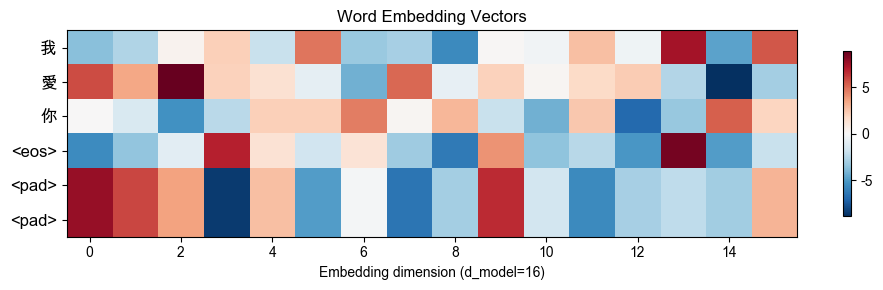

In [6]:
# ── Visualization: Embedding heatmap ──
tokens = [src_id2token[i] for i in src_input[0].tolist()]

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(embedded[0].detach().numpy(), aspect="auto", cmap="RdBu_r")
ax.set_yticks(range(len(tokens)))
ax.set_yticklabels(tokens, fontsize=12)
ax.set_xlabel(f"Embedding dimension (d_model={d_model})")
ax.set_title("Word Embedding Vectors")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

<a id='section-3'></a>
## Section 3: Positional Encoding

Unlike RNNs, Transformers process all tokens in parallel — they have **no inherent notion of order**. Positional encoding injects position information by adding a fixed pattern to the embeddings.

From the paper:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Each position gets a unique pattern of sines and cosines at different frequencies.

In [7]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""

    def __init__(self, d_model: int, max_len: int = 100) -> None:
        super().__init__()
        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )  # (d_model/2,)

        pe[:, 0::2] = torch.sin(position * div_term)  # Even indices: sin
        pe[:, 1::2] = torch.cos(position * div_term)  # Odd indices: cos

        pe = pe.unsqueeze(0)  # (1, max_len, d_model) — broadcast over batch
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add positional encoding to input embeddings.

        Args:
            x: (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)
        """
        return x + self.pe[:, : x.size(1), :]


# Demo
pos_encoder = PositionalEncoding(d_model)

print("Before positional encoding:")
print_shape("embedded", embedded)

encoded = pos_encoder(embedded)
print("\nAfter positional encoding:")
print_shape("encoded (embed + PE)", encoded)

print("\nThe PE is simply added to the embedding — same shape, new information.")

Before positional encoding:
  embedded                       → [1, 6, 16]

After positional encoding:
  encoded (embed + PE)           → [1, 6, 16]

The PE is simply added to the embedding — same shape, new information.


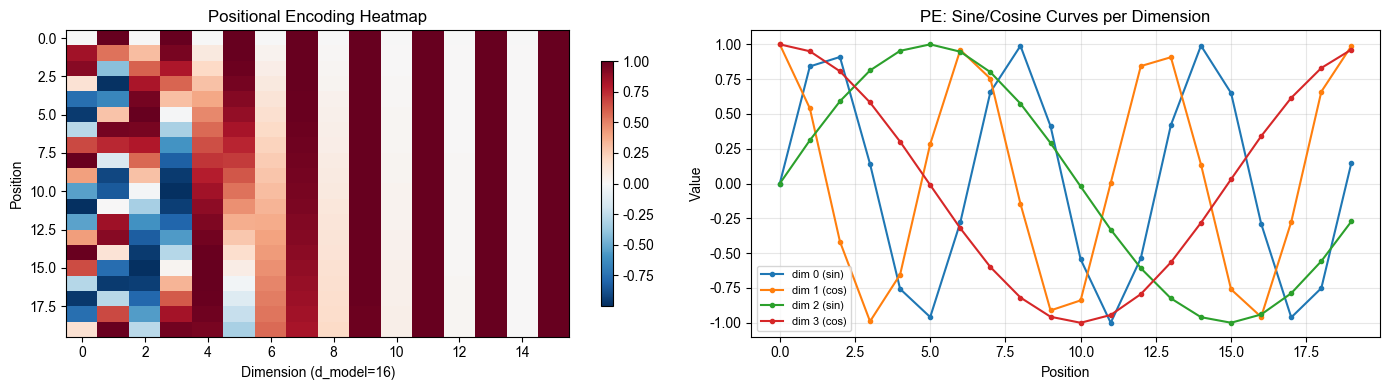

Notice: Lower dimensions have higher frequency, higher dimensions have lower frequency.
This gives each position a unique 'fingerprint'.


In [8]:
# ── Visualization: Positional Encoding patterns ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: PE heatmap
pe_vals = pos_encoder.pe[0, :20, :].numpy()  # First 20 positions
im = axes[0].imshow(pe_vals, aspect="auto", cmap="RdBu_r")
axes[0].set_xlabel(f"Dimension (d_model={d_model})")
axes[0].set_ylabel("Position")
axes[0].set_title("Positional Encoding Heatmap")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Right: Individual sine/cosine curves
positions = np.arange(20)
for dim_idx in [0, 1, 2, 3]:
    label = f"dim {dim_idx} ({'sin' if dim_idx % 2 == 0 else 'cos'})"
    axes[1].plot(positions, pe_vals[:, dim_idx], label=label, marker="o", markersize=3)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Value")
axes[1].set_title("PE: Sine/Cosine Curves per Dimension")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: Lower dimensions have higher frequency, higher dimensions have lower frequency.")
print("This gives each position a unique 'fingerprint'.")

<a id='section-4'></a>
## Section 4: Scaled Dot-Product Attention

The core mechanism of the Transformer. Think of it as a **soft dictionary lookup**:

- **Q** (Query): "What am I looking for?"
- **K** (Key): "What do I contain?" 
- **V** (Value): "What information do I provide?"

The formula:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

We scale by $\sqrt{d_k}$ to prevent the dot products from growing too large (which would push softmax into regions with tiny gradients).

In [9]:
def scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute scaled dot-product attention.

    Args:
        Q: (..., seq_len_q, d_k)
        K: (..., seq_len_k, d_k)
        V: (..., seq_len_k, d_v)
        mask: optional mask, broadcastable to (..., seq_len_q, seq_len_k)

    Returns:
        output: (..., seq_len_q, d_v)
        attention_weights: (..., seq_len_q, seq_len_k)
    """
    d_k = Q.size(-1)
    print("  Step-by-step attention:")
    print_shape("Q", Q)
    print_shape("K", K)
    print_shape("V", V)

    # Step 1: QK^T
    scores = torch.matmul(Q, K.transpose(-2, -1))  # (..., seq_q, seq_k)
    print_shape("QK^T (raw scores)", scores)

    # Step 2: Scale
    scores = scores / math.sqrt(d_k)
    print(f"  {'Scale by √d_k':30s} → ÷ {math.sqrt(d_k):.2f}")

    # Step 3: Mask (optional)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
        print(f"  {'Mask applied':30s} → -inf where mask=0")

    # Step 4: Softmax
    attn_weights = F.softmax(scores, dim=-1)
    print_shape("Attention weights (softmax)", attn_weights)

    # Step 5: Weighted sum of V
    output = torch.matmul(attn_weights, V)
    print_shape("Output (weights × V)", output)

    return output, attn_weights

In [10]:
# ── Demo: Self-attention on the encoded source sentence ──
# In self-attention, Q = K = V = the same input
print("Self-attention on: 我 愛 你 <eos> <pad> <pad>")
print("=" * 50)

# Use the positionally-encoded embeddings
Q = K = V = encoded  # (1, 6, 16)

attn_output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"\nEach token's output is a weighted combination of all Value vectors.")
print(f"The weights show how much each token 'attends to' every other token.")

Self-attention on: 我 愛 你 <eos> <pad> <pad>
  Step-by-step attention:
  Q                              → [1, 6, 16]
  K                              → [1, 6, 16]
  V                              → [1, 6, 16]
  QK^T (raw scores)              → [1, 6, 6]
  Scale by √d_k                  → ÷ 4.00
  Attention weights (softmax)    → [1, 6, 6]
  Output (weights × V)           → [1, 6, 16]

Each token's output is a weighted combination of all Value vectors.
The weights show how much each token 'attends to' every other token.


In [11]:
# ── Manual verification: weighted sum for token 0 ("我") ──
print("Manual verification for token '我' (position 0):")
print(f"  Attention weights for '我': {attn_weights[0, 0].detach().numpy().round(3)}")
print(f"  Tokens: {[src_id2token[i] for i in src_input[0].tolist()]}")

# Manually compute weighted sum
manual_output = torch.zeros(d_model)
for i in range(encoded.size(1)):
    manual_output += attn_weights[0, 0, i].detach() * V[0, i].detach()

auto_output = attn_output[0, 0].detach()
print(f"\n  Auto output[0,:4]:   {auto_output[:4].numpy().round(4)}")
print(f"  Manual output[0,:4]: {manual_output[:4].numpy().round(4)}")
print(f"  Match: {torch.allclose(auto_output, manual_output, atol=1e-5)}")

Manual verification for token '我' (position 0):
  Attention weights for '我': [1. 0. 0. 0. 0. 0.]
  Tokens: ['我', '愛', '你', '<eos>', '<pad>', '<pad>']

  Auto output[0,:4]:   [-3.6553 -1.6325  0.3121  3.1032]
  Manual output[0,:4]: [-3.6553 -1.6325  0.3121  3.1032]
  Match: True


In [ ]:
# ── Visualization: Attention weights heatmap ──
tokens = [src_id2token[i] for i in src_input[0].tolist()]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights[0].detach().numpy(), cmap="Blues", vmin=0)
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticklabels(tokens, fontsize=11)
ax.set_xlabel("Attends to (Key)")
ax.set_ylabel("Token (Query)")
ax.set_title("Self-Attention Weights")

# Add value annotations
for i in range(len(tokens)):
    for j in range(len(tokens)):
        val = attn_weights[0, i, j].item()
        color = "white" if val > 0.3 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

<a id='section-5'></a>
## Section 5: Multi-Head Attention

Instead of doing one big attention, the Transformer splits the embedding into **multiple heads**. Each head can learn to attend to different types of relationships (e.g., one head for syntax, another for semantics).

Process:
1. Project Q, K, V through separate linear layers
2. Split into `n_heads` parallel attention operations
3. Apply scaled dot-product attention to each head
4. Concatenate all heads
5. Project back through a final linear layer

In [ ]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Attention mechanism."""

    def __init__(self, d_model: int, n_heads: int) -> None:
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Linear projections for Q, K, V and output
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.attn_weights: torch.Tensor | None = None  # Store for visualization

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: torch.Tensor | None = None,
        verbose: bool = False,
    ) -> torch.Tensor:
        batch_size = query.size(0)

        if verbose:
            print(f"  MultiHeadAttention (h={self.n_heads}, d_k={self.d_k}):")
            print_shape("Input query", query)

        # 1. Linear projections
        Q = self.W_q(query)  # (batch, seq, d_model)
        K = self.W_k(key)
        V = self.W_v(value)

        if verbose:
            print_shape("After W_q projection", Q)

        # 2. Split into heads: (batch, seq, d_model) → (batch, n_heads, seq, d_k)
        Q = Q.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        if verbose:
            print_shape("After split into heads", Q)

        # 3. Scaled dot-product attention (per head)
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn_weights = F.softmax(scores, dim=-1)
        self.attn_weights = attn_weights.detach()  # Save for viz
        attn_output = torch.matmul(attn_weights, V)

        if verbose:
            print_shape("Attention output (per head)", attn_output)

        # 4. Concatenate heads: (batch, n_heads, seq, d_k) → (batch, seq, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        if verbose:
            print_shape("After concat heads", attn_output)

        # 5. Final linear projection
        output = self.W_o(attn_output)

        if verbose:
            print_shape("After W_o projection", output)

        return output

In [ ]:
# Demo
mha = MultiHeadAttention(d_model, n_heads)
mha_output = mha(encoded, encoded, encoded, verbose=True)

In [ ]:
# ── Visualization: Per-head attention weights ──
tokens = [src_id2token[i] for i in src_input[0].tolist()]

fig, axes = plt.subplots(1, n_heads, figsize=(6 * n_heads, 5))
if n_heads == 1:
    axes = [axes]

for h in range(n_heads):
    ax = axes[h]
    weights = mha.attn_weights[0, h].numpy()
    im = ax.imshow(weights, cmap="Blues", vmin=0)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_title(f"Head {h + 1}", fontsize=13)
    ax.set_xlabel("Key")
    if h == 0:
        ax.set_ylabel("Query")

    for i in range(len(tokens)):
        for j in range(len(tokens)):
            val = weights[i, j]
            color = "white" if val > 0.3 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.suptitle("Multi-Head Self-Attention Weights", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Each head learns different attention patterns!")

<a id='section-6'></a>
## Section 6: Masked Attention (Decoder)

During training, the decoder sees the **entire target sequence** at once. But at position `i`, it should only attend to positions `≤ i` — it can't peek at future tokens! This is enforced with a **causal mask** (lower-triangular matrix).

Without masking, the model would "cheat" by looking at the answer.

In [ ]:
def create_causal_mask(seq_len: int) -> torch.Tensor:
    """Create a lower-triangular causal mask.

    Returns:
        (1, 1, seq_len, seq_len) — broadcastable over batch and heads.
        1 = attend, 0 = block.
    """
    mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)
    return mask


# Demo with target sequence
tgt_input = example_tgt.unsqueeze(0)  # (1, 6)
tgt_tokens = [tgt_id2token[i] for i in tgt_input[0].tolist()]

tgt_embed = nn.Embedding(tgt_vocab_size, d_model)
tgt_encoded = pos_encoder(tgt_embed(tgt_input) * math.sqrt(d_model))

seq_len_tgt = tgt_input.size(1)
causal_mask = create_causal_mask(seq_len_tgt)

print(f"Target tokens: {tgt_tokens}")
print(f"\nCausal mask (1=attend, 0=block):")
print(causal_mask[0, 0].int().numpy())
print(f"\nAt position 2 ('love'), the model can see: <sos>, i, love")
print(f"But NOT: you, <eos>, <pad>")

In [ ]:
# ── Demo: Masked self-attention on the target ──
mha_masked = MultiHeadAttention(d_model, n_heads)
masked_output = mha_masked(tgt_encoded, tgt_encoded, tgt_encoded, mask=causal_mask, verbose=False)

# ── Visualization: Masked attention ──
fig, axes = plt.subplots(1, n_heads, figsize=(6 * n_heads, 5))
if n_heads == 1:
    axes = [axes]

for h in range(n_heads):
    ax = axes[h]
    weights = mha_masked.attn_weights[0, h].numpy()
    im = ax.imshow(weights, cmap="Purples", vmin=0)
    ax.set_xticks(range(len(tgt_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(tgt_tokens, fontsize=10)
    ax.set_yticklabels(tgt_tokens, fontsize=10)
    ax.set_title(f"Head {h + 1} (Masked)", fontsize=13)
    ax.set_xlabel("Key")
    if h == 0:
        ax.set_ylabel("Query")

    for i in range(len(tgt_tokens)):
        for j in range(len(tgt_tokens)):
            val = weights[i, j]
            color = "white" if val > 0.3 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.suptitle("Masked Self-Attention (Decoder) — Lower Triangular", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Notice the upper-right triangle is zero — future tokens are blocked!")

<a id='section-7'></a>
## Section 7: Layer Normalization

Layer normalization stabilizes training by normalizing each sample's features to have zero mean and unit variance. Combined with **residual connections**, it allows gradients to flow through deep networks.

Pattern: `LayerNorm(x + sublayer(x))`

In [ ]:
# Demo: Layer normalization
layer_norm = nn.LayerNorm(d_model)

# Before normalization
x = encoded[0, 0]  # First token's vector
print(f"Before LayerNorm:")
print(f"  Mean: {x.mean().item():.4f}")
print(f"  Std:  {x.std().item():.4f}")
print(f"  Values: {x.detach().numpy().round(2)}")

# After normalization
x_norm = layer_norm(x)
print(f"\nAfter LayerNorm:")
print(f"  Mean: {x_norm.mean().item():.6f} (≈ 0)")
print(f"  Std:  {x_norm.std(correction=0).item():.4f} (≈ 1)")
print(f"  Values: {x_norm.detach().numpy().round(2)}")

In [ ]:
# Demo: Residual connection + LayerNorm
print("Residual connection pattern:")
print("  output = LayerNorm(x + sublayer(x))")

sublayer_output = mha(encoded, encoded, encoded)  # Self-attention
residual_output = layer_norm(encoded + sublayer_output)

print(f"\nShapes:")
print_shape("x (input)", encoded)
print_shape("sublayer(x)", sublayer_output)
print_shape("x + sublayer(x)", encoded + sublayer_output)
print_shape("LayerNorm(x + sublayer(x))", residual_output)
print("\nAll shapes stay the same — residual connections are shape-preserving.")

<a id='section-8'></a>
## Section 8: Feed-Forward Network

After attention, each position passes through the same two-layer feed-forward network independently:

$$\text{FFN}(x) = \text{ReLU}(x W_1 + b_1) W_2 + b_2$$

Shape: `d_model → d_ff → d_model` (expand then compress).

This gives the model per-position nonlinear processing power.

In [ ]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""

    def __init__(self, d_model: int, d_ff: int) -> None:
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(F.relu(self.linear1(x)))


# Demo
ffn = FeedForward(d_model, d_ff)

print(f"Feed-Forward Network: {d_model} → {d_ff} → {d_model}")
print_shape("Input", encoded)

ffn_output = ffn(encoded)
print_shape("After FFN", ffn_output)

In [ ]:
# ── Full sub-layer demo: Attention → Add&Norm → FFN → Add&Norm ──
print("Full encoder sub-layer flow:")
print("=" * 50)

norm1 = nn.LayerNorm(d_model)
norm2 = nn.LayerNorm(d_model)

x = encoded
print_shape("1. Input x", x)

# Self-attention sub-layer
attn_out = mha(x, x, x)
print_shape("2. Self-Attention(x)", attn_out)

x = norm1(x + attn_out)
print_shape("3. LayerNorm(x + attn)", x)

# FFN sub-layer
ffn_out = ffn(x)
print_shape("4. FFN(x)", ffn_out)

x = norm2(x + ffn_out)
print_shape("5. LayerNorm(x + ffn)", x)

print("\nThis is one complete encoder layer!")

<a id='section-9'></a>
## Section 9: Full Encoder

The encoder consists of:
1. Word embedding + positional encoding
2. N identical encoder layers, each containing:
   - Multi-head self-attention + Add & Norm
   - Feed-forward network + Add & Norm

In [ ]:
class EncoderLayer(nn.Module):
    """One encoder layer: self-attention + FFN, each with residual + norm."""

    def __init__(self, d_model: int, n_heads: int, d_ff: int) -> None:
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(
        self, x: torch.Tensor, src_mask: torch.Tensor | None = None
    ) -> torch.Tensor:
        # Self-attention + residual + norm
        attn_output = self.self_attn(x, x, x, mask=src_mask)
        x = self.norm1(x + attn_output)
        # FFN + residual + norm
        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)
        return x


class Encoder(nn.Module):
    """Full Transformer Encoder: embedding + PE + N encoder layers."""

    def __init__(
        self, vocab_size: int, d_model: int, n_heads: int, d_ff: int, n_layers: int, max_len: int = 100
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)]
        )
        self.d_model = d_model

    def forward(
        self, src: torch.Tensor, src_mask: torch.Tensor | None = None
    ) -> torch.Tensor:
        """Args: src (batch, seq_len) → Returns: (batch, seq_len, d_model)"""
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, src_mask)
        return x


# Demo
encoder = Encoder(src_vocab_size, d_model, n_heads, d_ff, n_layers)

print(f"Encoder: {n_layers} layers, vocab={src_vocab_size}, d_model={d_model}")
print_shape("Input tokens", src_input)

encoder_output = encoder(src_input)
print_shape("Encoder output", encoder_output)

print(f"\nEach source token now has a context-aware representation of dimension {d_model}.")

<a id='section-10'></a>
## Section 10: Full Decoder

The decoder is similar to the encoder but with an extra sub-layer:
1. **Masked self-attention** — attend only to previous target tokens
2. **Cross-attention** — Q from decoder, K and V from encoder output
3. **Feed-forward network**

Cross-attention is how the decoder "reads" the source sentence.

In [ ]:
class DecoderLayer(nn.Module):
    """One decoder layer: masked self-attn + cross-attn + FFN."""

    def __init__(self, d_model: int, n_heads: int, d_ff: int) -> None:
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(
        self,
        x: torch.Tensor,
        encoder_output: torch.Tensor,
        tgt_mask: torch.Tensor | None = None,
        src_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        # 1. Masked self-attention
        self_attn_output = self.self_attn(x, x, x, mask=tgt_mask)
        x = self.norm1(x + self_attn_output)

        # 2. Cross-attention: Q from decoder, K/V from encoder
        cross_attn_output = self.cross_attn(x, encoder_output, encoder_output, mask=src_mask)
        x = self.norm2(x + cross_attn_output)

        # 3. FFN
        ffn_output = self.ffn(x)
        x = self.norm3(x + ffn_output)

        return x


class Decoder(nn.Module):
    """Full Transformer Decoder."""

    def __init__(
        self, vocab_size: int, d_model: int, n_heads: int, d_ff: int, n_layers: int, max_len: int = 100
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)]
        )
        self.fc_out = nn.Linear(d_model, vocab_size)  # Project to vocab
        self.d_model = d_model

    def forward(
        self,
        tgt: torch.Tensor,
        encoder_output: torch.Tensor,
        tgt_mask: torch.Tensor | None = None,
        src_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """Args: tgt (batch, tgt_len) → Returns: (batch, tgt_len, tgt_vocab_size)"""
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, encoder_output, tgt_mask, src_mask)
        logits = self.fc_out(x)
        return logits

In [ ]:
# Demo
decoder = Decoder(tgt_vocab_size, d_model, n_heads, d_ff, n_layers)

tgt_mask = create_causal_mask(tgt_input.size(1))

print(f"Decoder: {n_layers} layers, vocab={tgt_vocab_size}, d_model={d_model}")
print_shape("Target input", tgt_input)
print_shape("Encoder output (K,V source)", encoder_output)

decoder_output = decoder(tgt_input, encoder_output, tgt_mask=tgt_mask)
print_shape("Decoder output (logits)", decoder_output)
print(f"\nOutput has {tgt_vocab_size} values per position (one per target vocab token).")
print(f"We take argmax to get the predicted token.")

In [ ]:
# ── Visualization: Cross-attention (English → Chinese) ──
# Get cross-attention weights from the last decoder layer
cross_attn_weights = decoder.layers[-1].cross_attn.attn_weights
src_tokens = [src_id2token[i] for i in src_input[0].tolist()]
tgt_disp_tokens = [tgt_id2token[i] for i in tgt_input[0].tolist()]

fig, ax = plt.subplots(figsize=(7, 5))
# Average over heads
avg_weights = cross_attn_weights[0].mean(dim=0).numpy()
im = ax.imshow(avg_weights, cmap="Oranges", vmin=0)
ax.set_xticks(range(len(src_tokens)))
ax.set_yticks(range(len(tgt_disp_tokens)))
ax.set_xticklabels(src_tokens, fontsize=11)
ax.set_yticklabels(tgt_disp_tokens, fontsize=11)
ax.set_xlabel("Source (Chinese) — Key")
ax.set_ylabel("Target (English) — Query")
ax.set_title("Cross-Attention: How Decoder Reads the Source")

for i in range(len(tgt_disp_tokens)):
    for j in range(len(src_tokens)):
        val = avg_weights[i, j]
        color = "white" if val > 0.3 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("Note: Weights are random before training. After training, we'll see meaningful alignments.")

<a id='section-11'></a>
## Section 11: Complete Transformer

Now we combine the Encoder and Decoder into the full Transformer model.

In [ ]:
class Transformer(nn.Module):
    """Full Transformer: Encoder + Decoder."""

    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model: int,
        n_heads: int,
        d_ff: int,
        n_layers: int,
        max_len: int = 100,
    ) -> None:
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, n_heads, d_ff, n_layers, max_len)
        self.decoder = Decoder(tgt_vocab_size, d_model, n_heads, d_ff, n_layers, max_len)

    def forward(
        self,
        src: torch.Tensor,
        tgt: torch.Tensor,
        tgt_mask: torch.Tensor | None = None,
        src_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """Forward pass.

        Args:
            src: (batch, src_len) — source token ids
            tgt: (batch, tgt_len) — target token ids
            tgt_mask: causal mask for decoder
            src_mask: optional padding mask for source

        Returns:
            (batch, tgt_len, tgt_vocab_size) — logits
        """
        encoder_output = self.encoder(src, src_mask)
        decoder_output = self.decoder(tgt, encoder_output, tgt_mask, src_mask)
        return decoder_output

In [ ]:
# Demo: Full forward pass with shape trace
model = Transformer(src_vocab_size, tgt_vocab_size, d_model, n_heads, d_ff, n_layers)

tgt_mask = create_causal_mask(tgt_input.size(1))

print("Full Transformer Forward Pass")
print("=" * 50)
print_shape("Source tokens", src_input)
print(f"  Values: {[src_id2token[i] for i in src_input[0].tolist()]}")

print_shape("Target tokens", tgt_input)
print(f"  Values: {[tgt_id2token[i] for i in tgt_input[0].tolist()]}")

# Forward
with torch.no_grad():
    logits = model(src_input, tgt_input, tgt_mask=tgt_mask)

print_shape("\nOutput logits", logits)
print(f"  → {logits.size(-1)} values per position (target vocab size)")

# Predicted tokens
pred_ids = logits.argmax(dim=-1)
print(f"\nPredicted token ids: {pred_ids[0].tolist()}")
print(f"Predicted tokens: {[tgt_id2token[i] for i in pred_ids[0].tolist()]}")
print(f"(Random predictions before training — this is expected!)")

In [ ]:
# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nFor comparison, the original Transformer (base) had ~65M parameters.")
print(f"Our toy model is {65_000_000 / total_params:.0f}× smaller.")

<a id='section-12'></a>
## Section 12: Training & Translation Demo

Now let's train our tiny Transformer to translate all 6 Chinese→English sentence pairs. With such a small dataset, the model should memorize everything quickly.

In [ ]:
# ── Prepare training data ──
# Source: Chinese tokens + <eos> + padding
# Target input: <sos> + English tokens + padding (decoder input)
# Target output: English tokens + <eos> + padding (what we want the model to predict)

max_src_len = 6
max_tgt_len = 7  # Need room for <sos> + tokens + <eos>

src_tensors: list[torch.Tensor] = []
tgt_input_tensors: list[torch.Tensor] = []
tgt_output_tensors: list[torch.Tensor] = []

for src_sent, tgt_sent in sentence_pairs:
    # Source: tokens + <eos> + <pad>...
    src_t = encode_sentence(src_sent, src_token2id, max_src_len, add_eos=True)
    # Target input: <sos> + tokens + <pad>... (no <eos> — that's what we predict)
    tgt_in = encode_sentence(tgt_sent, tgt_token2id, max_tgt_len, add_sos=True, add_eos=False)
    # Target output: tokens + <eos> + <pad>... (shifted by 1 from input)
    tgt_out = encode_sentence(tgt_sent, tgt_token2id, max_tgt_len, add_sos=False, add_eos=True)

    src_tensors.append(src_t)
    tgt_input_tensors.append(tgt_in)
    tgt_output_tensors.append(tgt_out)

src_batch = torch.stack(src_tensors)        # (6, max_src_len)
tgt_in_batch = torch.stack(tgt_input_tensors)  # (6, max_tgt_len)
tgt_out_batch = torch.stack(tgt_output_tensors) # (6, max_tgt_len)

print("Training data shapes:")
print_shape("Source batch", src_batch)
print_shape("Target input batch", tgt_in_batch)
print_shape("Target output batch", tgt_out_batch)

print("\nExample pair 0:")
print(f"  Source:     {[src_id2token[i] for i in src_batch[0].tolist()]}")
print(f"  Target in:  {[tgt_id2token[i] for i in tgt_in_batch[0].tolist()]}")
print(f"  Target out: {[tgt_id2token[i] for i in tgt_out_batch[0].tolist()]}")
print("\nNotice: target input is shifted right by 1 position relative to target output.")
print("The decoder learns to predict the NEXT token at each position.")

In [ ]:
# ── Training loop ──
torch.manual_seed(42)
model = Transformer(src_vocab_size, tgt_vocab_size, d_model, n_heads, d_ff, n_layers)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)  # Ignore padding in loss

n_epochs = 300
losses: list[float] = []

model.train()
for epoch in range(n_epochs):
    tgt_mask = create_causal_mask(tgt_in_batch.size(1))

    # Forward pass
    logits = model(src_batch, tgt_in_batch, tgt_mask=tgt_mask)  # (6, tgt_len, vocab)

    # Reshape for cross-entropy: (batch*tgt_len, vocab) vs (batch*tgt_len,)
    loss = criterion(logits.view(-1, tgt_vocab_size), tgt_out_batch.view(-1))

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1:3d}/{n_epochs} — Loss: {loss.item():.4f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

In [ ]:
# ── Plot training loss ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color="#2196F3", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Loss")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Greedy decoding (translation) ──
def greedy_decode(
    model: Transformer,
    src: torch.Tensor,
    max_len: int,
    sos_id: int,
    eos_id: int,
) -> list[int]:
    """Generate translation one token at a time.

    Args:
        model: trained Transformer
        src: (1, src_len) source token ids
        max_len: maximum output length
        sos_id: start-of-sentence token id
        eos_id: end-of-sentence token id

    Returns:
        List of predicted token ids
    """
    model.eval()
    with torch.no_grad():
        # Encode source once
        encoder_output = model.encoder(src)

        # Start with <sos>
        tgt_ids = [sos_id]

        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_ids], dtype=torch.long)  # (1, current_len)
            tgt_mask = create_causal_mask(len(tgt_ids))

            logits = model.decoder(tgt_tensor, encoder_output, tgt_mask=tgt_mask)
            next_token = logits[0, -1, :].argmax().item()  # Greedy: take the most likely

            tgt_ids.append(next_token)

            if next_token == eos_id:
                break

    return tgt_ids

In [ ]:
# ── Translate all training sentences ──
print("Translation Results")
print("=" * 60)

all_correct = True
for i, (src_sent, tgt_sent) in enumerate(sentence_pairs):
    src_t = encode_sentence(src_sent, src_token2id, max_src_len).unsqueeze(0)
    pred_ids = greedy_decode(model, src_t, max_len=10, sos_id=SOS, eos_id=EOS)

    # Convert ids to tokens (skip <sos> and <eos>)
    pred_tokens = [
        tgt_id2token[tid] for tid in pred_ids
        if tid not in (SOS, EOS, PAD)
    ]

    correct = pred_tokens == tgt_sent
    status = "OK" if correct else "WRONG"
    if not correct:
        all_correct = False

    print(f"  {' '.join(src_sent):12s} → {' '.join(pred_tokens):20s} [{status}]")
    if not correct:
        print(f"  {'':12s}   Expected: {' '.join(tgt_sent)}")

print(f"\n{'All translations correct!' if all_correct else 'Some translations failed — try more epochs.'}")

In [ ]:
# ── Visualization: Cross-attention during translation ──
# Pick a sentence to visualize step-by-step
viz_idx = 4  # "我 是 學生" → "i am a student"
viz_src_sent, viz_tgt_sent = sentence_pairs[viz_idx]

viz_src = encode_sentence(viz_src_sent, src_token2id, max_src_len).unsqueeze(0)

# Run greedy decode and collect cross-attention at each step
model.eval()
with torch.no_grad():
    encoder_out = model.encoder(viz_src)
    tgt_ids = [SOS]
    step_attentions: list[np.ndarray] = []
    step_tokens: list[str] = []

    for step in range(10):
        tgt_tensor = torch.tensor([tgt_ids], dtype=torch.long)
        tgt_mask = create_causal_mask(len(tgt_ids))
        _ = model.decoder(tgt_tensor, encoder_out, tgt_mask=tgt_mask)

        # Get cross-attention from last layer, average over heads
        cross_attn = model.decoder.layers[-1].cross_attn.attn_weights
        avg_attn = cross_attn[0].mean(dim=0).numpy()  # (tgt_len, src_len)

        logits = model.decoder.fc_out(
            model.decoder.layers[-1](
                model.decoder.pos_encoding(
                    model.decoder.embedding(tgt_tensor) * math.sqrt(d_model)
                ),
                encoder_out,
                tgt_mask,
            )
        )
        next_token = logits[0, -1, :].argmax().item()

        step_attentions.append(avg_attn[-1])  # Attention of the last generated position
        step_tokens.append(tgt_id2token[next_token])

        tgt_ids.append(next_token)
        if next_token == EOS:
            break

# Plot
src_labels = viz_src_sent + ["<eos>"] + ["<pad>"] * (max_src_len - len(viz_src_sent) - 1)
n_steps = len(step_tokens)

fig, axes = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3))
if n_steps == 1:
    axes = [axes]

for s in range(n_steps):
    ax = axes[s]
    attn_vals = step_attentions[s]
    ax.barh(range(len(src_labels)), attn_vals, color="#FF9800")
    ax.set_yticks(range(len(src_labels)))
    ax.set_yticklabels(src_labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_title(f"→ '{step_tokens[s]}'", fontsize=11)
    if s == 0:
        ax.set_ylabel("Source token")

plt.suptitle(
    f"Cross-Attention Step-by-Step: '{' '.join(viz_src_sent)}' → '{' '.join(viz_tgt_sent)}'",
    fontsize=13, y=1.05,
)
plt.tight_layout()
plt.show()

print("Each bar chart shows which source tokens the decoder attends to when generating each target token.")

<a id='section-13'></a>
## Section 13: Summary & Further Reading

### Key Concepts Recap

| Component | Purpose |
|-----------|--------|
| **Word Embedding** | Map tokens to dense vectors |
| **Positional Encoding** | Inject position information (sin/cos) |
| **Scaled Dot-Product Attention** | Soft lookup: how much each token attends to others |
| **Multi-Head Attention** | Multiple parallel attention patterns |
| **Causal Mask** | Prevent decoder from seeing future tokens |
| **Layer Normalization** | Stabilize training |
| **Residual Connections** | Help gradients flow through deep networks |
| **Feed-Forward Network** | Per-position nonlinear transformation |
| **Encoder** | Builds context-aware representations of source |
| **Decoder** | Generates target tokens using source context |
| **Cross-Attention** | How the decoder "reads" the encoder output |

### What We Simplified

- **Tiny dimensions**: d_model=16 vs 512, so we could print full tensors
- **No dropout**: Real Transformers use dropout=0.1 for regularization
- **No learning rate schedule**: The paper uses a warmup + decay schedule
- **No beam search**: We used greedy decoding; beam search gives better translations
- **No byte-pair encoding**: We used word-level tokens; real systems use subword tokenization
- **Toy dataset**: 6 sentences vs millions in real training
- **No padding mask**: We ignored padding in attention for simplicity

### Further Reading

1. **Original Paper**: [Attention Is All You Need](https://arxiv.org/abs/1706.03762) (Vaswani et al., 2017)
2. **The Illustrated Transformer**: [jalammar.github.io/illustrated-transformer](https://jalammar.github.io/illustrated-transformer/) — Outstanding visual guide
3. **The Annotated Transformer**: [nlp.seas.harvard.edu/annotated-transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — Line-by-line code walkthrough
4. **3Blue1Brown — Attention in Transformers**: Visual intuition for attention mechanics